Before running this notebook, run `pip install pynapple dandi lindi matplotlib` in the notebook environment. 

In [1]:
# Get the DANDI API URL for a file in a dandiset
from dandi.dandiapi import DandiAPIClient

dandiset_id = "218201"
filepath = "sub-mouse-1/sub-mouse-1_ses-None_ecephys.nwb"

# This dandiset is on the sandbox archive, not the main archive so pass in the sandbox API URL
with DandiAPIClient(api_url="https://api.sandbox.dandiarchive.org/api") as client:
    asset = client.get_dandiset(dandiset_id, "draft").get_asset_by_path(filepath)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

# OR copy URL from asset metadata in
# https://sandbox.dandiarchive.org/dandiset/218201/draft/files?location=sub-mouse-1&page=1
s3_url = "https://api.sandbox.dandiarchive.org/api/assets/9aad5ba1-9906-46a5-8f6f-611978dfa2e6/download/"

In [2]:
import lindi
import pynwb

f = lindi.LindiH5pyFile.from_hdf5_file(s3_url, local_cache=lindi.LocalCache(cache_dir="lindi_cache"))
io = pynwb.NWBHDF5IO(file=f)
nwbfile = io.read()
nwbfile

Data type,object
Shape,"(6,)"
Array size,48.00 bytes
Chunk shape,"(6,)"
Compression,None
Compression opts,None
Uncompressed size (bytes),48
Data type,float64
Shape,"(1675486, 28)"
Array size,357.92 MiB
Chunk shape,"(13090, 1)"


In [3]:
import pynapple as nap

nap_nwb = nap.NWBFile(nwbfile)
nap_nwb

-
┍━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys       │ Type        │
┝━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units      │ TsGroup     │
│ trials     │ IntervalSet │
│ lfp_area_3 │ TsdFrame    │
│ lfp_area_2 │ TsdFrame    │
│ lfp_area_1 │ TsdFrame    │
┕━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

In [4]:
peth = nap.compute_perievent(
    timestamps=nap_nwb["units"][0], 
    tref=nap.Ts(nap_nwb["trials"]["stim_start"].to_numpy()), 
    minmax=(-0.1, 0.2), 
    time_unit="s"
)

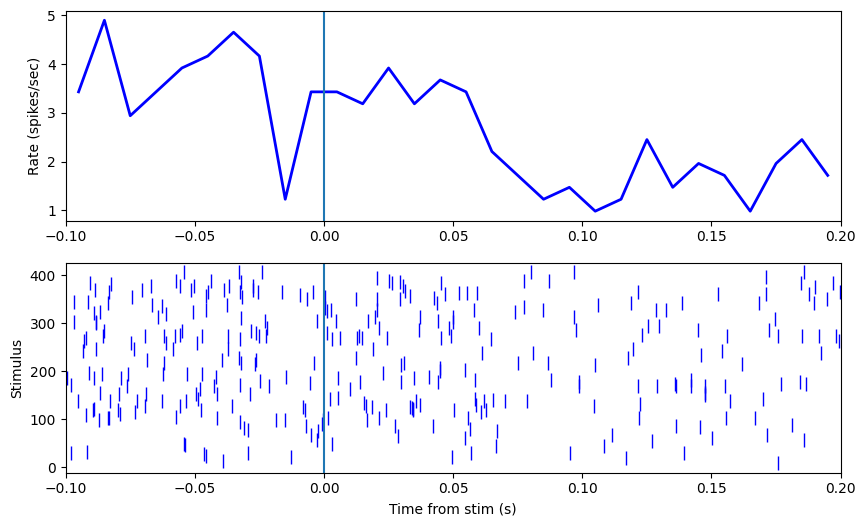

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(np.mean(peth.count(0.01), 1) / 0.01, linewidth=2, color="blue")
plt.xlim(-0.1, 0.2)
plt.ylabel("Rate (spikes/sec)")
plt.axvline(0.0)
plt.subplot(212)
plt.plot(peth.to_tsd(), "|", markersize=10, color="blue", mew=1)
plt.xlabel("Time from stim (s)")
plt.ylabel("Stimulus")
plt.xlim(-0.1, 0.2)
plt.axvline(0.0)

In [6]:
# This code demonstrates the slower, fsspec-based streaming method
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
from pynwb import NWBHDF5IO

# Get the DANDI API URL for a file in a dandiset
from dandi.dandiapi import DandiAPIClient

dandiset_id = "218201"
filepath = "sub-mouse-1/sub-mouse-1_ses-None_ecephys.nwb"

# This dandiset is on the sandbox archive, not the main archive so pass in the sandbox API URL
with DandiAPIClient(api_url="https://api.sandbox.dandiarchive.org/api") as client:
    asset = client.get_dandiset(dandiset_id, "draft").get_asset_by_path(filepath)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

s3_url

# first, create a virtual filesystem based on the http protocol
fs = fsspec.filesystem("http")

# create a cache to save downloaded data to disk (optional)
fs = CachingFileSystem(
    fs=fs,
    cache_storage="nwb-cache",  # Local folder for the cache
)

# next, open the file
file = h5py.File(fs.open(s3_url, "rb"))
io = NWBHDF5IO(file=file)
io.read()

Data type,object
Shape,"(6,)"
Array size,48.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),48
Compressed size (bytes),96
Compression ratio,0.5
Data type,float64
Shape,"(1675486, 28)"
